# Evaluate fixed-SIS magnification-aware SR

This notebook evaluates the Stage D/E run produced by `train_mag.py`.

It checks:

- training and validation loss histories;
- the fixed SIS magnification and source-information maps;
- LR re-degradation residuals;
- raw-fine versus adaptive HR source structure;
- source-plane back-projection mean and multiple-image variance.

The physics convention is surface-brightness conservation. Magnification is an information/resolution map, not an intensity multiplier.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

import data
from differentiable_lensing import DifferentiableLensing
from physics_losses import (
    SourcePlaneIntensityConsistency,
    magnification_adaptive_loss,
    magnification_adaptive_source_grid,
)
from psf import apply_psf, build_psf_kernel
from sisr import SISR

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## Configuration

Change only these paths/sample selectors first.

In [3]:
RUN_DIR = Path("outputs_corrected/smoke_mag_corrected")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "best.pt"
PSF_PATH_OVERRIDE = None  # e.g. Path("/new/location/psf.fits")
VAL_CLASS = "cdm"      # one of: no_sub, axion, cdm
VAL_INDEX = 0

assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"
#assert (RUN_DIR / "physics_maps.pt").exists(), "physics_maps.pt is missing"
assert (RUN_DIR / "history.json").exists(), "history.json is missing"

In [5]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
args = checkpoint["args"]
history = json.loads((RUN_DIR / "history.json").read_text())
#physics_maps = torch.load(RUN_DIR / "physics_maps.pt", map_location="cpu")

print("Checkpoint epoch:", checkpoint["epoch"] + 1)
print("Best validation loss:", checkpoint.get("best_val_loss"))
#print("Fixed theta_E [arcsec]:", args["theta_e"])
#print("LR / HR pixel scales:", args["resolution"], args["target_resolution"])
#print("PSF type:", args["psf_type"])
#print("Stored PSF path:", args.get("psf_path"))

C:\Users\upraj\AppData\Local\Temp\ipykernel_15348\217345076.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

Checkpoint epoch: 2
Best validation loss: None


## Training curves

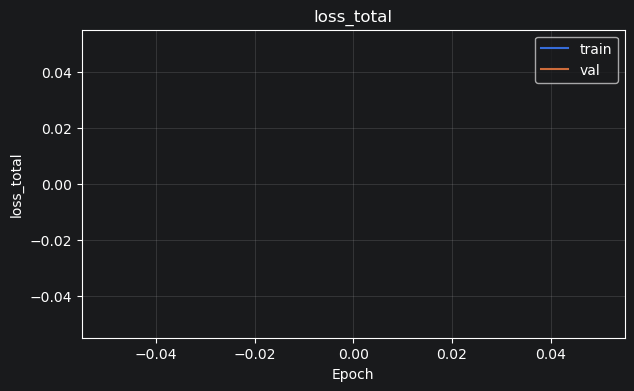

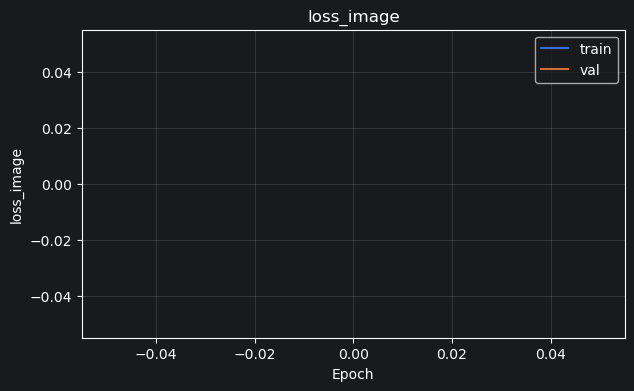

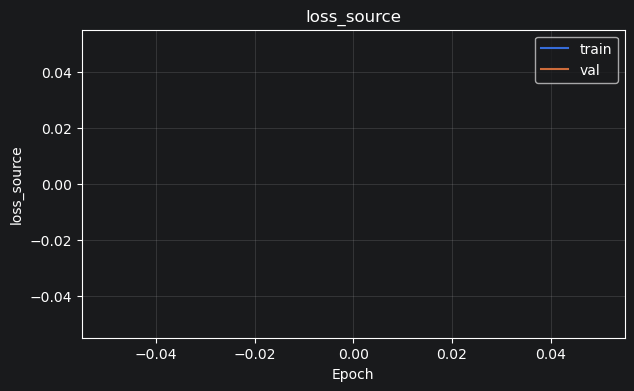

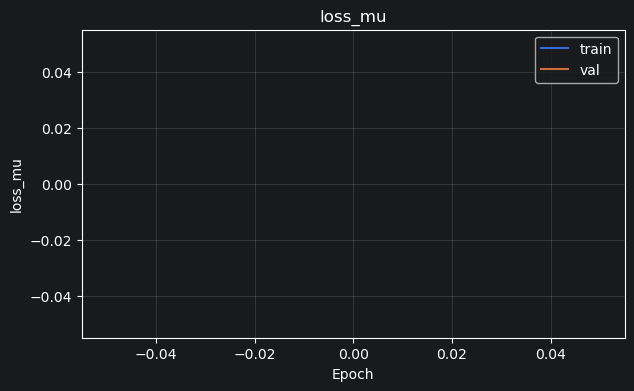

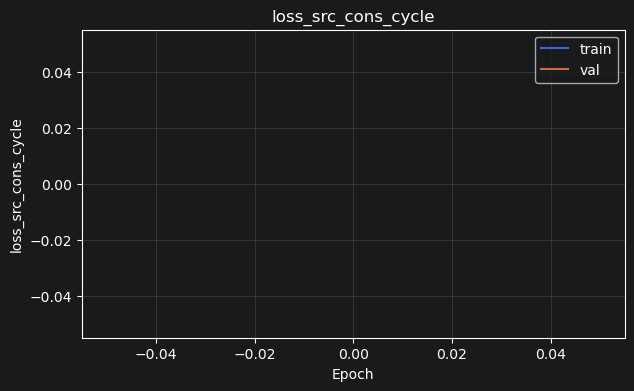

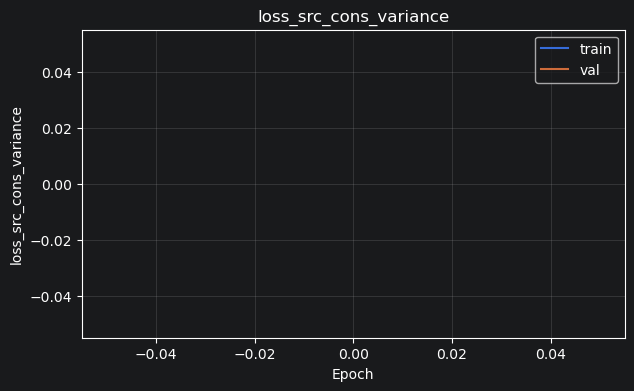

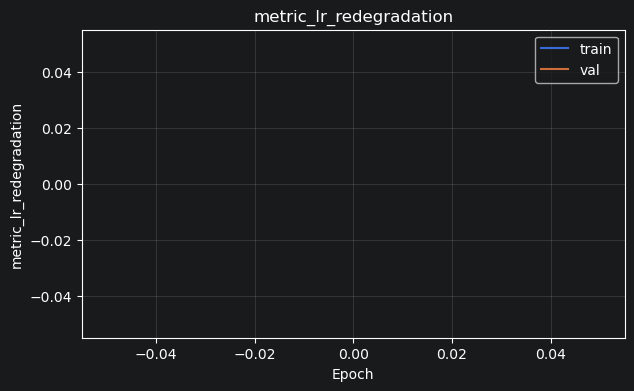

In [6]:
def plot_history(keys):
    for key in keys:
        plt.figure(figsize=(7, 4))
        for split in ("train", "val"):
            rows = history[split]
            epochs = [row["epoch"] for row in rows]
            values = [row.get(key, np.nan) for row in rows]
            plt.plot(epochs, values, label=split)
        plt.xlabel("Epoch")
        plt.ylabel(key)
        plt.title(key)
        plt.legend()
        plt.grid(alpha=0.25)
        plt.show()

plot_history([
    "loss_total",
    "loss_image",
    "loss_source",
    "loss_mu",
    "loss_src_cons_cycle",
    "loss_src_cons_variance",
    "metric_lr_redegradation",
])

## Fixed SIS geometry and source information

In [7]:
map_items = [
    ("Signed magnification", physics_maps["signed_magnification_image"][0, 0]),
    ("Clipped |magnification|", physics_maps["absolute_magnification_image"][0, 0]),
    ("Image information", physics_maps["image_information"][0, 0]),
    ("Source information (LR)", physics_maps["source_information_lr"][0, 0]),
    ("Source information (HR)", physics_maps["source_information_hr"][0, 0]),
    ("Effective contributors", physics_maps["source_effective_contributors_lr"][0, 0]),
]

for title, image in map_items:
    plt.figure(figsize=(5, 4))
    plt.imshow(image.numpy(), origin="lower")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

NameError: name 'physics_maps' is not defined

## Rebuild the trained pipeline

In [8]:
model = SISR(
    magnification=args["magnification"],
    n_mag=args["n_mag"],
    residual_depth=args["residual_depth"],
    in_channels=args["in_channels"],
    latent_channel_count=args["latent_space_size"],
).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

lensing_module = DifferentiableLensing(
    device=DEVICE,
    alpha=None,
    target_resolution=args["target_resolution"],
    target_shape=args["target_shape"],
).to(DEVICE)

forward_mappings = [
    torch.load("scatter_to_log_128.pt", map_location=DEVICE).to(DEVICE),
    torch.load("forward_from_log_128.pt", map_location=DEVICE).to(DEVICE),
    torch.load("scatter_from_log_128.pt", map_location=DEVICE).to(DEVICE),
]
backward_mapping = torch.load(
    "sparse_grid_fracs_euclid_backward.pt", map_location=DEVICE
).to(DEVICE)

psf_path = str(PSF_PATH_OVERRIDE) if PSF_PATH_OVERRIDE is not None else args.get("psf_path")
psf_kernel = build_psf_kernel(
    psf_type=args["psf_type"],
    fwhm_arcsec=args["psf_fwhm_arcsec"],
    pixscale_arcsec=args["target_resolution"],
    beta=args["psf_beta"],
    kernel_size=args.get("psf_kernel_size"),
    path=psf_path,
    ellipticity_q=args["psf_ellipticity_q"],
    angle_deg=args["psf_angle_deg"],
    fits_hdu=args.get("psf_fits_hdu", 0),
    fits_extname=args.get("psf_fits_extname"),
    fits_crop_size=args.get("psf_fits_crop_size"),
    source_pixscale_arcsec=args.get("psf_source_pixscale_arcsec"),
    device=DEVICE,
)

source_information_hr = physics_maps["source_information_hr"].to(DEVICE)
source_consistency = SourcePlaneIntensityConsistency(
    backward_mapping,
    source_shape=(args["image_shape"], args["image_shape"]),
    min_effective_contributors=args["src_cons_min_neff"],
    variance_weight=args["src_cons_variance_weight"],
    normalize_by_source_power=True,
).to(DEVICE)

KeyError: 'in_channels'

## Run one validation example

In [9]:
dataset = data.LensingDataset("val/", [VAL_CLASS], args["val_samples_per_class"])
lr_image = dataset[VAL_INDEX].unsqueeze(0).float().to(DEVICE)
while lr_image.ndim > 4 and lr_image.shape[1] == 1:
    lr_image = lr_image.squeeze(1)
if lr_image.ndim == 3:
    lr_image = lr_image.unsqueeze(1)

with torch.no_grad():
    reconstructed_source = lensing_module.cross_grid_fill(lr_image, [backward_mapping])
    fine_source = model(torch.cat([reconstructed_source, lr_image], dim=1))
    adaptive_source, adaptive_diag = magnification_adaptive_source_grid(
        fine_source,
        source_information_hr,
        medium_factor=args["adaptive_medium_factor"],
        coarse_factor=args["adaptive_coarse_factor"],
    )
    intrinsic_hr = lensing_module.cross_grid_fill(adaptive_source, forward_mappings)
    convolved_hr = apply_psf(intrinsic_hr, psf_kernel)
    degraded_lr = F.interpolate(
        convolved_hr,
        scale_factor=1.0 / args["effective_magnification"],
        mode=args["downsample_mode"],
    )
    intrinsic_lr = F.interpolate(
        intrinsic_hr,
        scale_factor=1.0 / args["effective_magnification"],
        mode=args["downsample_mode"],
    )
    source_lr = F.interpolate(
        adaptive_source,
        scale_factor=1.0 / args["effective_magnification"],
        mode=args["downsample_mode"],
    )
    src_cons_loss, src_diag = source_consistency(intrinsic_lr, source_lr)
    mu_loss = magnification_adaptive_loss(fine_source, adaptive_source, source_information_hr)
    residual_lr = degraded_lr - lr_image

print("L_mu:", float(mu_loss))
print("L_src-cons:", float(src_cons_loss))
print("  cycle:", float(src_diag["cycle_loss"]))
print("  variance:", float(src_diag["variance_loss"]))
print("LR MSE:", float(F.mse_loss(degraded_lr, lr_image)))

NameError: name 'lensing_module' is not defined

In [10]:
images = [
    ("LR observation", lr_image[0, 0]),
    ("LR source reconstruction", reconstructed_source[0, 0]),
    ("Raw fine HR source", fine_source[0, 0]),
    ("Adaptive HR source", adaptive_source[0, 0]),
    ("Intrinsic HR lensed image", intrinsic_hr[0, 0]),
    ("PSF-convolved HR image", convolved_hr[0, 0]),
    ("Re-degraded LR prediction", degraded_lr[0, 0]),
    ("LR residual", residual_lr[0, 0]),
]

for title, image in images:
    plt.figure(figsize=(5, 4))
    plt.imshow(image.detach().cpu().numpy(), origin="lower")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

NameError: name 'reconstructed_source' is not defined

## Source-plane consistency diagnostics

In [12]:
diagnostic_images = [
    ("Downsampled adaptive source", source_lr[0, 0]),
    ("Back-projected mean image brightness", src_diag["backprojected_mean"][0, 0]),
    ("Contributor variance", src_diag["variance_map"][0, 0]),
    ("Multi-image/effective-contributor mask", src_diag["multi_image_mask"][0, 0]),
]
for title, image in diagnostic_images:
    plt.figure(figsize=(5, 4))
    plt.imshow(image.detach().cpu().numpy(), origin="lower")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

NameError: name 'source_lr' is not defined

## Does the adaptive grid suppress unsupported detail?

The fine-minus-adaptive residual should be concentrated more strongly where the information map is low. This is a diagnostic, not a proof that every retained high-frequency feature is astrophysical.

In [13]:
info = source_information_hr.expand_as(fine_source)
hf_power = (fine_source - adaptive_source).square()
low_mask = (info < 0.33).float()
high_mask = (info > 0.67).float()

def masked_mean(x, mask):
    return float((x * mask).sum() / mask.sum().clamp_min(1.0))

summary = {
    "hf_power_low_information": masked_mean(hf_power, low_mask),
    "hf_power_high_information": masked_mean(hf_power, high_mask),
    "lr_mse": float(F.mse_loss(degraded_lr, lr_image)),
    "mu_loss": float(mu_loss),
    "src_cons_total": float(src_cons_loss),
    "src_cons_cycle": float(src_diag["cycle_loss"]),
    "src_cons_variance": float(src_diag["variance_loss"]),
}
summary

NameError: name 'source_information_hr' is not defined

## Interpretation checklist

Before moving to learnable SIS/SIE/shear:

1. Compare against `train.py` using the same seed, dataset fraction, PSF, and epoch count.
2. Repeat with `--mu-weight 0` and with `--src-cons-weight 0`.
3. Check that validation `loss_src_cons_variance` decreases rather than only training loss.
4. Inspect residuals for a ring at the SIS critical curve; such a ring indicates geometry/weighting artifacts.
5. Repeat at three seeds. A single visually favorable sample is insufficient evidence.
6. The adaptive source may retain more fine structure in high-information regions, but the LR re-degradation constraint remains the primary measurement-consistency test.